<a href="https://colab.research.google.com/github/fathimapb/ML-DL_Projects/blob/main/Disease_risk/disease_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

** AI-Based Early Disease Risk Prediction System **

Problem Statement (Real World Based)

Healthcare systems across the world face increasing pressure due to the rising number of patients suffering from chronic and lifestyle-related diseases such as diabetes, heart disease, and hypertension. A major challenge is that many of these conditions develop silently and are often diagnosed only at advanced stages, when treatment becomes more complex, expensive, and less effective.

Currently, healthcare providers rely heavily on periodic check-ups and manual assessments, which may not always capture early warning signs. Additionally, the growing volume of patient data—ranging from medical history to lifestyle habits—makes it difficult for clinicians to analyze all relevant factors efficiently.

This leads to:

Delayed diagnosis of critical conditions
Increased healthcare costs
Higher risk of severe complications or mortality
Limited ability to provide personalized preventive care

To address this issue, there is a need for an intelligent system that can analyze patient data proactively and identify individuals at high risk before the condition worsens.

This project proposes an AI-based disease risk prediction system that utilizes patient demographic details, medical history, and lifestyle information to predict the likelihood of disease occurrence. By applying machine learning techniques, the system can uncover hidden patterns and relationships within the data.

The solution aims to:

Enable early detection and intervention
Assist doctors in data-driven decision making
Support preventive healthcare strategies
Improve overall patient outcomes

This system can act as a decision-support tool for healthcare professionals, helping shift the focus from reactive treatment to proactive prevention.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/disease_risk_dataset.csv")
df

,age,gender,bmi,blood_pressure,cholesterol,smoking,physical_activity,family_history,glucose_level,disease_risk
0,69,Male,25.1,120.0,157.0,Yes,Medium,Yes,96.0,1
1,32,Female,32.8,141.0,180.0,No,Low,No,134.0,0
2,89,Female,35.4,114.0,254.0,No,Medium,No,130.0,0
3,78,Male,22.5,119.0,198.0,No,Medium,Yes,94.0,0
4,38,Female,27.0,126.0,192.0,No,High,No,123.0,0
...,...,...,...,...,...,...,...,...,...,...
59995,76,Female,33.0,107.0,183.0,Yes,Medium,No,158.0,0
59996,28,Male,26.7,89.0,137.0,Yes,Medium,Yes,75.0,0
59997,52,Male,29.3,113.0,132.0,No,Medium,No,142.0,0
59998,66,Female,22.8,103.0,152.0,Yes,Low,Yes,135.0,0


In [ ]:
df.head()

,age,gender,bmi,blood_pressure,cholesterol,smoking,physical_activity,family_history,glucose_level,disease_risk
0,69,Male,25.1,120.0,157.0,Yes,Medium,Yes,96.0,1
1,32,Female,32.8,141.0,180.0,No,Low,No,134.0,0
2,89,Female,35.4,114.0,254.0,No,Medium,No,130.0,0
3,78,Male,22.5,119.0,198.0,No,Medium,Yes,94.0,0
4,38,Female,27.0,126.0,192.0,No,High,No,123.0,0


In [ ]:
df.tail()

,age,gender,bmi,blood_pressure,cholesterol,smoking,physical_activity,family_history,glucose_level,disease_risk
59995,76,Female,33.0,107.0,183.0,Yes,Medium,No,158.0,0
59996,28,Male,26.7,89.0,137.0,Yes,Medium,Yes,75.0,0
59997,52,Male,29.3,113.0,132.0,No,Medium,No,142.0,0
59998,66,Female,22.8,103.0,152.0,Yes,Low,Yes,135.0,0
59999,61,Female,21.2,107.0,221.0,No,Medium,Yes,127.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                60000 non-null  int64  
 1   gender             60000 non-null  object 
 2   bmi                60000 non-null  float64
 3   blood_pressure     60000 non-null  float64
 4   cholesterol        60000 non-null  float64
 5   smoking            60000 non-null  object 
 6   physical_activity  60000 non-null  object 
 7   family_history     60000 non-null  object 
 8   glucose_level      60000 non-null  float64
 9   disease_risk       60000 non-null  int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 4.6+ MB


In [ ]:
df.isnull().sum()

,0
age,0
gender,0
bmi,0
blood_pressure,0
cholesterol,0
smoking,0
physical_activity,0
family_history,0
glucose_level,0
disease_risk,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(60000, 10)

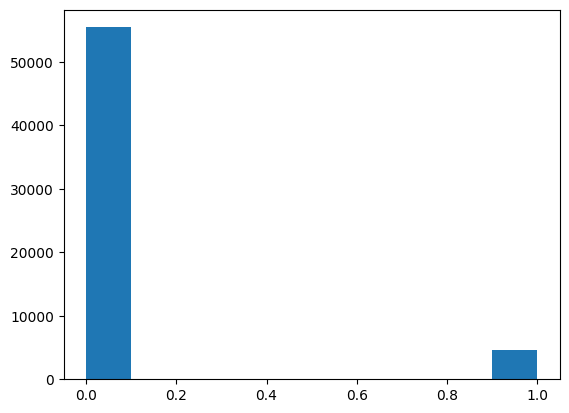

In [ ]:
plt.hist(df['disease_risk'])
plt.show()

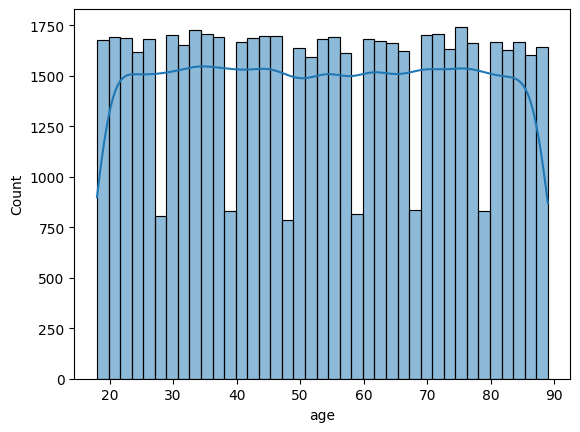

In [ ]:
sns.histplot(df['age'], kde=True)
plt.show()

In [ ]:
df.head()

,age,gender,bmi,blood_pressure,cholesterol,smoking,physical_activity,family_history,glucose_level,disease_risk
0,69,Male,25.1,120.0,157.0,Yes,Medium,Yes,96.0,1
1,32,Female,32.8,141.0,180.0,No,Low,No,134.0,0
2,89,Female,35.4,114.0,254.0,No,Medium,No,130.0,0
3,78,Male,22.5,119.0,198.0,No,Medium,Yes,94.0,0
4,38,Female,27.0,126.0,192.0,No,High,No,123.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                60000 non-null  int64  
 1   gender             60000 non-null  object 
 2   bmi                60000 non-null  float64
 3   blood_pressure     60000 non-null  float64
 4   cholesterol        60000 non-null  float64
 5   smoking            60000 non-null  object 
 6   physical_activity  60000 non-null  object 
 7   family_history     60000 non-null  object 
 8   glucose_level      60000 non-null  float64
 9   disease_risk       60000 non-null  int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 4.6+ MB


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['smoking'] = le.fit_transform(df['smoking'])
# df['physical_activity'] = le.fit_transform(df['physical_activity'])
df['family_history'] = le.fit_transform(df['family_history'])


In [ ]:
print(df['physical_activity'].unique())

['Medium' 'Low' 'High']


In [ ]:
df["physical_activity"].replace(['Low', 'Medium', 'High'],[1,2,3],inplace=True)

/tmp/ipykernel_8886/4284975585.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["physical_activity"].replace(['Low', 'Medium', 'High'],[1,2,3],inplace=True)
/tmp/ipykernel_8886/4284975585.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["physical_activity"].replace(['Low', 'Medium', 'Hig

In [ ]:
df


,age,gender,bmi,blood_pressure,cholesterol,smoking,physical_activity,family_history,glucose_level,disease_risk
0,69,1,25.1,120.0,157.0,1,2,1,96.0,1
1,32,0,32.8,141.0,180.0,0,1,0,134.0,0
2,89,0,35.4,114.0,254.0,0,2,0,130.0,0
3,78,1,22.5,119.0,198.0,0,2,1,94.0,0
4,38,0,27.0,126.0,192.0,0,3,0,123.0,0
...,...,...,...,...,...,...,...,...,...,...
59995,76,0,33.0,107.0,183.0,1,2,0,158.0,0
59996,28,1,26.7,89.0,137.0,1,2,1,75.0,0
59997,52,1,29.3,113.0,132.0,0,2,0,142.0,0
59998,66,0,22.8,103.0,152.0,1,1,1,135.0,0


In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Load your data (if not already loaded)
# df = pd.read_csv("your_file.csv")

# Define features and target
X = df.drop(columns=['disease_risk'])   # <-- replace 'target'
y = df['disease_risk']                  # <-- replace 'target'

# Train-test split (important: apply SMOTE only on training data)


# Apply SMOTE
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)



In [ ]:
import pandas as pd

df_resampled=pd.concat(
    [pd.DataFrame(X_resampled , columns=X.columns),
     pd.Series(y_resampled,name=y.name)],
    axis=1
)

print(df_resampled.head())

   age  gender   bmi  blood_pressure  cholesterol  smoking  physical_activity  \
0   69       1  25.1           120.0        157.0        1                  2   
1   32       0  32.8           141.0        180.0        0                  1   
2   89       0  35.4           114.0        254.0        0                  2   
3   78       1  22.5           119.0        198.0        0                  2   
4   38       0  27.0           126.0        192.0        0                  3   

   family_history  glucose_level  disease_risk  
0               1           96.0             1  
1               0          134.0             0  
2               0          130.0             0  
3               1           94.0             0  
4               0          123.0             0  


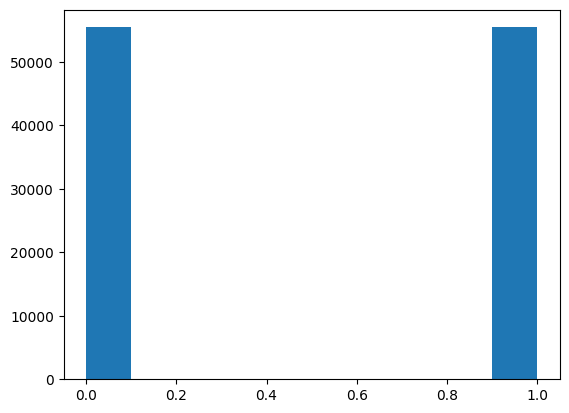

In [ ]:
plt.hist(df_resampled['disease_risk'])
plt.show()

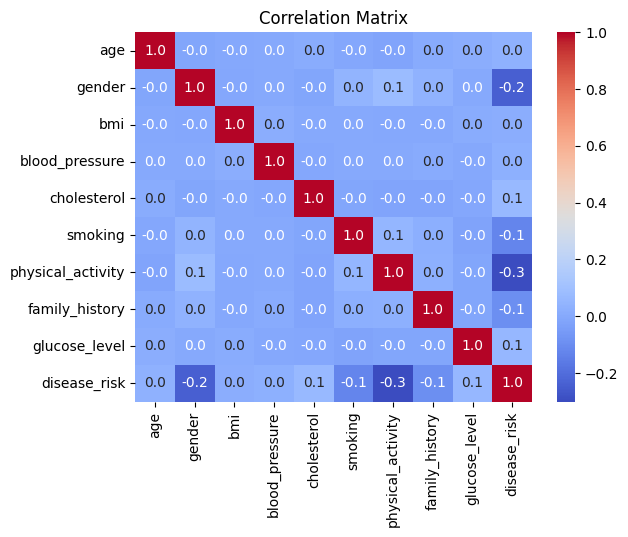

In [ ]:
corr_matrix =df_resampled.corr()

sns.heatmap(corr_matrix,annot=True, fmt='0.01f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df_resampled.drop(['age','bmi','blood_pressure'],axis=1,inplace=True)

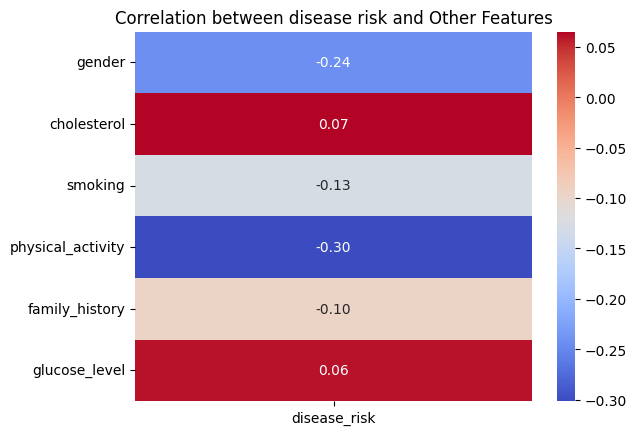

In [ ]:
survived_corr = df_resampled.corr()['disease_risk']

survived_corr = survived_corr.drop('disease_risk')

sns.heatmap(survived_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between disease risk and Other Features')
plt.show()

In [ ]:
df_resampled.drop(['cholesterol','glucose_level'],axis=1,inplace=True)

<Axes: >

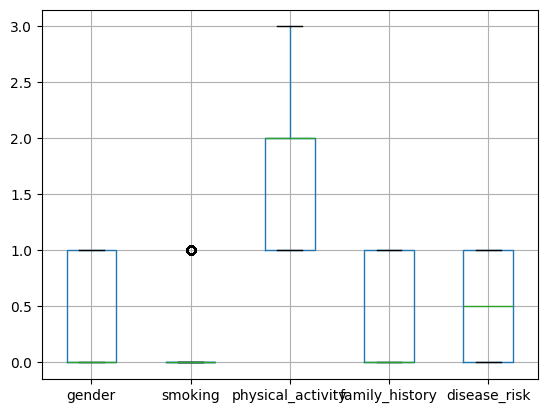

In [ ]:
df_resampled.boxplot()

In [ ]:
def remove_outliers_iqr(df_resampled, exclude_column):
    for col in df_resampled.columns:
        if col == exclude_column:
            continue
        Q1 = df_resampled[col].quantile(0.25)
        Q3 = df_resampled[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_resampled = df_resampled[(df_resampled[col] >= lower_bound) & (df_resampled[col] <= upper_bound)]
    return df_resampled

df_cleaned = remove_outliers_iqr(df_resampled, exclude_column='disease_risk')
df_resampled=df_cleaned

In [ ]:
df_resampled.shape

(84428, 5)

In [ ]:
df_resampled.head()

,gender,smoking,physical_activity,family_history,disease_risk
1,0,0,1,0,0
2,0,0,2,0,0
3,1,0,2,1,0
4,0,0,3,0,0
6,0,0,1,0,0


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler



features = ['gender', 'smoking', 'physical_activity','family_history']

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df_resampled[features])

scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd



X = df_resampled[['gender', 'smoking', 'physical_activity','family_history']]
y = df_resampled['disease_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.67


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd



X = df_resampled[['gender', 'smoking', 'physical_activity','family_history']]
y = df_resampled['disease_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.67


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd

X = df_resampled[['gender', 'smoking', 'physical_activity','family_history']]
y = df_resampled['disease_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


model=SVC(kernel='linear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.67


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

X=df_resampled[['gender', 'smoking', 'physical_activity','family_history']]
y=df_resampled ['disease_risk']

X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size=0.25, random_state=42)

model=RandomForestClassifier()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.67


In [ ]:
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

In [ ]:
X=df_resampled.drop('disease_risk',axis=1)
y=df_resampled['disease_risk']

kf=KFold(n_splits=5,shuffle=True,random_state=42)
model=LogisticRegression(max_iter=1000)
best_accuracy=0
best_fold=1

best_X_train=None
best_y_train=None
best_X_test=None
best_y_test=None
best_y_pred=None

for fold,(train_index,test_index) in enumerate(kf.split(X),1):
  X_train,X_test=X.iloc[train_index],X.iloc[test_index]
  y_train,y_test=y.iloc[train_index],y.iloc[test_index]

  model.fit(X_train,y_train)

  y_pred=model.predict(X_test)
  acc=accuracy_score(y_test,y_pred)
  print(f"Fold {fold} Accuracy: {acc:.2f}")

  if acc > best_accuracy:
    best_accuracy=acc
    best_fold=fold
    best_X_train=X_train
    best_y_train=y_train
    best_X_test=X_test
    best_y_test=y_test
    best_y_pred=y_pred

print(f"\nBest Fold:{best_fold} with accuracy:{best_accuracy:.2f}")

Fold 1 Accuracy: 0.67
Fold 2 Accuracy: 0.67
Fold 3 Accuracy: 0.67
Fold 4 Accuracy: 0.67
Fold 5 Accuracy: 0.68

Best Fold:5 with accuracy:0.68


In [ ]:
model=LogisticRegression()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.6762214983713355

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.6754515842463725

In [ ]:
from sklearn.svm import SVC
model=SVC()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.6754515842463725

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.6754515842463725

In [ ]:
from keras import preprocessing
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_classification

In [ ]:
model=Sequential()
model.add(Dense(256,input_shape=(4,),activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(X_train,y_train,epochs=80,batch_size=32)

Epoch 1/80
2111/2111 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6676 - loss: 0.6129
Epoch 2/80
2111/2111 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6717 - loss: 0.6079
Epoch 3/80
2111/2111 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6710 - loss: 0.6073
Epoch 4/80
2111/2111 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6719 - loss: 0.6072
Epoch 5/80
2111/2111 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6711 - loss: 0.6071
Epoch 6/80
2111/2111 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6725 - loss: 0.6068
Epoch 7/80
2111/2111 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6722 - loss: 0.6067
Epoch 8/80
2111/2111 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6714 - loss: 0.6064
Epoch 9/80
2111/2111 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6730 - loss: 0.6066
Epoch 10/80
2111/2111 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6719 - loss: 0.6063
Epoch 11/80
2111/2111 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6722 - loss: 0.6062
Epoch 12/80
2111/2111 ━━━━━━━

In [ ]:
probs=model.predict(np.expand_dims(X_test.iloc[0],axis=0))

pred_classes=np.round(probs).astype(int)

print("Probabilities:\n",probs.flatten())
print()
print("Predicted classes (by rounding):",pred_classes.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Probabilities:
 [0.3024255]

Predicted classes (by rounding): [0]


In [ ]:
loss,accuracy=model.evaluate(X_test,y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

528/528 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6755 - loss: 0.6037
Model Accuracy: 67.55%


**Conclusion**

The AI-Based Early Disease Risk Prediction System was successfully developed to predict the likelihood of disease occurrence using patient demographic, medical, and lifestyle data. The problem was formulated as a binary classification task, where the model predicts whether an individual is at risk (1) or not (0).

Among the models evaluated, Logistic Regression achieved the best performance with an accuracy of 67.62%. This indicates that the model is able to identify general trends and relationships between input features—such as age, BMI, blood pressure, cholesterol, and lifestyle habits—and disease risk. However, the predictive performance remains moderate, suggesting that the model does not fully capture the complexity of real-world health conditions.

The results highlight that:

 -Disease risk is influenced by a combination of medical and lifestyle factors, rather than a single variable
 -Linear models like Logistic Regression can identify basic relationships, but may miss complex interactions
 -The current dataset and features provide useful but incomplete information for highly accurate predictions

Despite its limitations, the system can still serve as a preliminary screening tool to help identify individuals who may require further medical evaluation. It can assist healthcare professionals in prioritizing high-risk patients and promoting early intervention strategies.

Insights

 -Factors such as glucose level, blood pressure, and BMI are likely strong contributors
 -Lifestyle variables (smoking, activity) also influence predictions
 -Model performance suggests non-linear relationships exist in the data

Limitations

 -Accuracy (~67%) is not sufficient for clinical decision-making alone
 -Possible class imbalance affecting results
 -Lack of advanced feature engineering
 -Logistic Regression may be too simple for complex medical patterns

Future Scope

To improve the system:

 -Use advanced models:
   -Random Forest (tuned)
   -Gradient Boosting (XGBoost, LightGBM)
   -Deep Learning
 -Perform feature engineering (risk scores, interactions)
 -Handle class imbalance (SMOTE, class weights)
 -Evaluate using:
   -Precision, Recall, F1-score
   -ROC-AUC Curve
 -Apply cross-validation
 -Add more real-world features (diet, stress, medical history depth)

Final Verdict

The project demonstrates that machine learning can assist in predicting disease risk, but achieving high reliability requires richer data, better feature engineering, and more advanced models. The current system is a good foundation for developing a more accurate and clinically useful decision-support tool.